# 2-D Ackley Function with the Artificial Bee Colony Algorithm

**Course:** CSE 4111 - Machine Learning
**Goal:** find a point close to $(0,0)$ where the Ackley function is close to $0$.

This is the same assignment as the Genetic Algorithm notebook - same function, same
range $[-5,5]^2$, same budget, same accuracy report. Only the search method changes.

The Artificial Bee Colony uses **50 bees: 25 employed bees sitting on 25 food sources,
plus 25 onlooker bees**. Each cycle has three phases, exactly as in the course slides:
employed bees search nearby, onlookers pick good sources by **roulette wheel**, and a
**scout** replaces any source that has stopped improving.

Run the cells from top to bottom.

## 1. Imports and display settings

- Import the numerical and plotting libraries used below.
- Set compact NumPy output and the honey colour scheme used throughout.
- The printed versions make the run easier to reproduce.

In [1]:
import math
from dataclasses import dataclass, replace

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

np.set_printoptions(precision=10, suppress=False, linewidth=110)

# The honey palette of our slide deck, so the figures and the deck match.
BROWN, AMBER, DEEP, HIVE, GREY = "#6F251B", "#FFC62A", "#E37E03", "#CB6C29", "#9A8F8C"
HONEY = LinearSegmentedColormap.from_list(
    "honey", ["#3B1410", "#6F251B", "#B04B26", "#E37E03", "#FFC62A", "#FFF0B8"])

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})

print("numpy      :", np.__version__)
print("matplotlib :", __import__("matplotlib").__version__)

numpy      : 2.4.2
matplotlib : 3.10.8


## 2. Control parameters (slide 20)

Slide 20 lists exactly six ABC control parameters, and we set all of them here.

- The colony has **50 bees**, matching the 50 chromosomes of the GA version.
- Slide 20 says employed bees are 50% of the swarm and onlookers the other 50%, so
  **25 food sources** and **25 onlookers**.
- `limit` is the number of failed tries a source is allowed before it is abandoned.
  The usual choice is $SN \times D = 25 \times 2 = 50$.
- The last block records our own implementation choices, which section 12 then tests.

In [2]:
@dataclass
class ABCSettings:
    """Every knob of the Artificial Bee Colony, in one place."""

    # --- the six control parameters of slide 20 ----------------------
    colony_size: int = 50            # total bees
    n_dimensions: int = 2            # food source = [x1, x2]
    limit: int = 50                  # failed tries before a source is abandoned
    n_scouts_per_cycle: int = 1      # "1 or can be more than 1"
    # employed bees and onlookers are each 50% of the colony -> see below

    # --- fixed by the assignment -------------------------------------
    lower: float = -5.0
    upper: float = 5.0
    max_cycles: int = 100            # stopping criterion 1

    # --- our own implementation choices ------------------------------
    fitness_kind: str = "karaboga"   # "karaboga" or "windowing"
    probability_kind: str = "plain"  # "plain" (the slide), "scaled", "rank"
    neighbour_kind: str = "one_dim"  # "one_dim" or "all_dims"
    use_onlookers: bool = True       # ablation switch only
    use_scouts: bool = True          # ablation switch only
    tolerance: float = 1e-10         # stopping criterion 2
    patience: int = 20               # ... held for this many cycles
    seed: int = 7                    # reproducibility

    @property
    def n_sources(self):
        """Food sources = employed bees = 50% of the colony."""
        return self.colony_size // 2

    @property
    def n_onlookers(self):
        """Onlookers are the other 50%."""
        return self.colony_size - self.n_sources


SETTINGS = ABCSettings()

print("colony size        =", SETTINGS.colony_size)
print("food sources (SN)  =", SETTINGS.n_sources, " (= employed bees)")
print("onlooker bees      =", SETTINGS.n_onlookers)
print("dimension (D)      =", SETTINGS.n_dimensions)
print("limit              =", SETTINGS.limit, " (= SN * D)")
print("max cycles         =", SETTINGS.max_cycles)
print()
for field, value in vars(SETTINGS).items():
    print(f"  {field:20s} = {value}")

colony size        = 50
food sources (SN)  = 25  (= employed bees)
onlooker bees      = 25
dimension (D)      = 2
limit              = 50  (= SN * D)
max cycles         = 100

  colony_size          = 50
  n_dimensions         = 2
  limit                = 50
  n_scouts_per_cycle   = 1
  lower                = -5.0
  upper                = 5.0
  max_cycles           = 100
  fitness_kind         = karaboga
  probability_kind     = plain
  neighbour_kind       = one_dim
  use_onlookers        = True
  use_scouts           = True
  tolerance            = 1e-10
  patience             = 20
  seed                 = 7


## 3. Ackley objective function

This cell implements

$$f(\mathbf{x})=-20e^{-0.2\sqrt{\frac{1}{n}\sum x_i^2}}-e^{\frac{1}{n}\sum\cos(2\pi x_i)}+20+e.$$

- It accepts one food source or a whole array of food sources.
- Lower values are better; the theoretical minimum is $f(0,0)=0$.
- The example calls provide a quick formula check.

In [3]:
def ackley(x, a=20.0, b=0.2, c=2.0 * math.pi):
    """Ackley objective value. Smaller is better.

    Parameters
    ----------
    x : array of shape (n_dimensions,) or (n_sources, n_dimensions)
    """
    x = np.asarray(x, dtype=float)
    n = x.shape[-1]

    mean_of_squares = np.sum(x ** 2, axis=-1) / n
    mean_of_cosines = np.sum(np.cos(c * x), axis=-1) / n

    exponential_part = -a * np.exp(-b * np.sqrt(mean_of_squares))
    cosine_part = -np.exp(mean_of_cosines)

    return exponential_part + cosine_part + a + math.e


GLOBAL_OPTIMUM = np.array([0.0, 0.0])

print("f(0, 0)             =", ackley(GLOBAL_OPTIMUM))
print("f(-4.0,  2.5)       =", ackley([-4.0, 2.5]))
print("f(-1.5, -1.0)       =", ackley([-1.5, -1.0]))
print("f on a whole colony :", ackley(np.array([[0.0, 0.0], [1.0, 0.0], [3.0, -2.0]])))

f(0, 0)             = 4.440892098500626e-16
f(-4.0,  2.5)       = 11.454215696941548
f(-1.5, -1.0)       = 6.219192055519926
f on a whole colony : [4.4408920985e-16 2.6375310921e+00 7.9889108105e+00]


## 4. View the search landscape

- Evaluate Ackley on a grid over $[-5,5]^2$.
- Draw a 3-D surface and a contour map.
- The ripples are local minima; the star marks the global minimum.

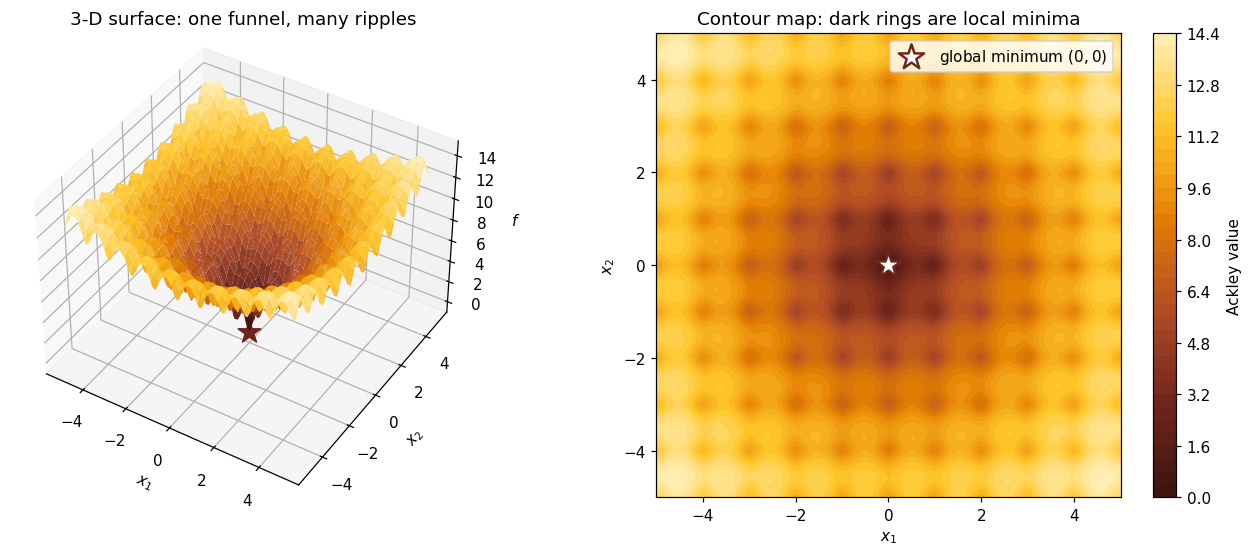

In [4]:
grid = np.linspace(SETTINGS.lower, SETTINGS.upper, 400)
X1, X2 = np.meshgrid(grid, grid)
Z = ackley(np.stack([X1, X2], axis=-1))

fig = plt.figure(figsize=(12.5, 5.0))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X1[::3, ::3], X2[::3, ::3], Z[::3, ::3],
                cmap=HONEY, linewidth=0, antialiased=True, alpha=0.97)
ax.scatter([0], [0], [0], color=BROWN, marker="*", s=240, depthshade=False)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$f$")
ax.set_title("3-D surface: one funnel, many ripples")
ax.view_init(elev=40, azim=-58)

ax = fig.add_subplot(1, 2, 2)
filled = ax.contourf(X1, X2, Z, levels=45, cmap=HONEY)
fig.colorbar(filled, ax=ax, label="Ackley value")
ax.scatter(0, 0, marker="*", s=300, color="white", edgecolor=BROWN, linewidth=1.6,
           zorder=5, label="global minimum $(0,0)$")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Contour map: dark rings are local minima")
ax.legend(loc="upper right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 5. View a one-dimensional slice

- Hold $x_2=0$ and vary $x_1$ from $-5$ to $5$.
- This makes the repeated local dips easier to see.
- The printed values compare the centre with nearby integer locations.

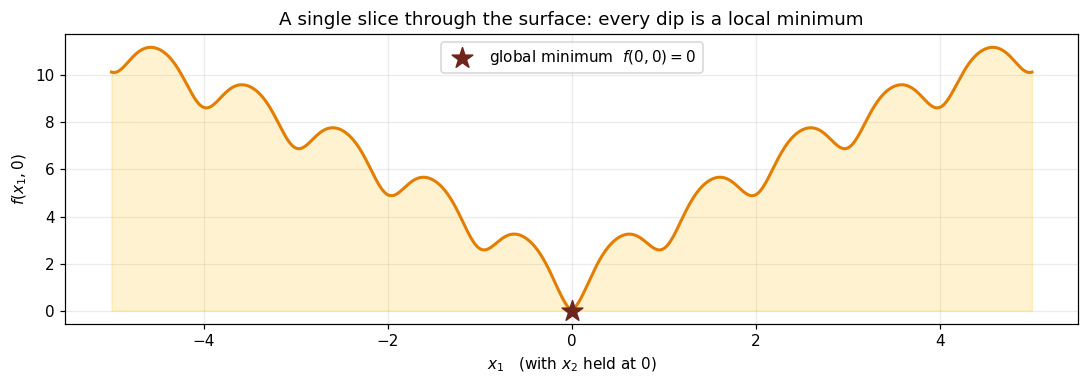

Local minima sit near integer x1 values:
f(0,0) = 0.000000   f(1,0) = 2.637531   f(2,0) = 4.927234   f(3,0) = 6.914978


In [5]:
line = np.linspace(-5, 5, 2000)
slice_values = ackley(np.stack([line, np.zeros_like(line)], axis=-1))

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(line, slice_values, color=DEEP, linewidth=2.0)
ax.fill_between(line, slice_values, color=AMBER, alpha=0.22)
ax.scatter([0], [0], color=BROWN, marker="*", s=200, zorder=5,
           label="global minimum  $f(0,0)=0$")
ax.set_xlabel("$x_1$   (with $x_2$ held at 0)")
ax.set_ylabel("$f(x_1, 0)$")
ax.set_title("A single slice through the surface: every dip is a local minimum")
ax.legend()
plt.tight_layout()
plt.show()

print("Local minima sit near integer x1 values:")
print("f(0,0) = %.6f   f(1,0) = %.6f   f(2,0) = %.6f   f(3,0) = %.6f"
      % (ackley([0, 0]), ackley([1, 0]), ackley([2, 0]), ackley([3, 0])))

## 6. Step 2 - initialise the food sources (slide 21)

Slide 21 gives the initialisation equation

$$x_{ij} = x_{\min,j} + \mathrm{rand}(0,1)\,(x_{\max,j} - x_{\min,j}),$$

with $i = 1,\ldots,SN$ and $j = 1,\ldots,D$.

- Draw 25 food sources uniformly from the allowed range.
- Each source holds two real coordinates: `[x1, x2]`.
- Every source also gets a **trial counter**, starting at 0. The scout phase uses it later.

In [6]:
def create_sources(rng, settings):
    """Step 2 - x_ij = x_min,j + rand(0,1) * (x_max,j - x_min,j)."""
    shape = (settings.n_sources, settings.n_dimensions)
    return settings.lower + rng.random(shape) * (settings.upper - settings.lower)


demo_rng = np.random.default_rng(SETTINGS.seed)
initial_sources = create_sources(demo_rng, SETTINGS)
initial_values = ackley(initial_sources)
initial_trials = np.zeros(SETTINGS.n_sources, dtype=int)

print("food sources shape :", initial_sources.shape)
print("coordinate range   : [%.4f, %.4f]" % (initial_sources.min(), initial_sources.max()))
print()
print("First five food sources")
print("  #        x1            x2          f(x1,x2)     trial")
for i in range(5):
    print("  %d   %+10.6f   %+10.6f   %10.6f   %5d"
          % (i, initial_sources[i, 0], initial_sources[i, 1],
             initial_values[i], initial_trials[i]))
print()
print("cycle 0 :  best %.6f   mean %.6f   worst %.6f"
      % (initial_values.min(), initial_values.mean(), initial_values.max()))

food sources shape : (25, 2)
coordinate range   : [-4.9627, 4.9550]

First five food sources
  #        x1            x2          f(x1,x2)     trial
  0    +1.250955    +3.972138     9.988756       0
  1    +2.756857    -2.747928    10.169675       0
  2    -1.998337    +3.735534    10.156918       0
  3    -4.947347    +3.212284    12.229430       0
  4    +2.970694    -0.320650     8.292024       0

cycle 0 :  best 3.188874   mean 9.717116   worst 12.229430


## 7. Plot cycle 0

- Show all 25 food sources on the Ackley landscape.
- Highlight the richest starting source and the known optimum.
- The sources are spread widely because the bees have learned nothing yet.

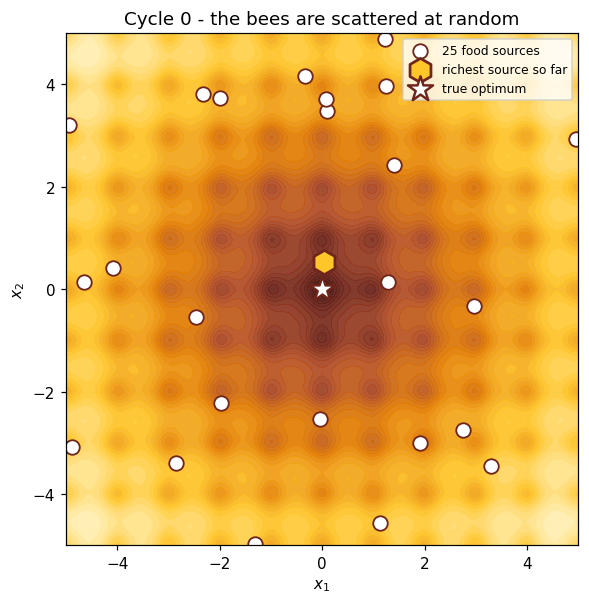

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.contourf(X1, X2, Z, levels=45, cmap=HONEY, alpha=0.93)
ax.scatter(initial_sources[:, 0], initial_sources[:, 1],
           s=90, color="white", edgecolor=BROWN, linewidth=1.2,
           label=f"{SETTINGS.n_sources} food sources")
best0 = int(np.argmin(initial_values))
ax.scatter(*initial_sources[best0], s=250, color=AMBER, edgecolor=BROWN,
           marker="h", linewidth=1.8, zorder=5, label="richest source so far")
ax.scatter(0, 0, marker="*", s=300, color="white", edgecolor=BROWN, linewidth=1.6,
           zorder=6, label="true optimum")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_aspect("equal")
ax.set_title("Cycle 0 - the bees are scattered at random")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Nectar amount: turning a minimisation into a maximisation

Roulette selection gives more chances to a **larger** number, but a **smaller** Ackley value is
better. The standard ABC fitness (the "nectar amount") fixes that:

$$fit_i = \begin{cases} \dfrac{1}{1+f_i} & f_i \ge 0 \\[1mm] 1+|f_i| & f_i < 0 \end{cases}$$

Ackley is never negative, so only the first line is ever used in this assignment.

- `windowing` is the alternative the GA notebook used; section 12 compares the two.
- Notice in the printout how similar the nectar values already are. Section 11 shows why that
  matters.

In [8]:
def to_fitness(values, kind="karaboga"):
    """Turn objective values (lower is better) into nectar amounts (higher is better)."""
    values = np.asarray(values, dtype=float)

    if kind == "karaboga":
        return np.where(values >= 0.0, 1.0 / (1.0 + values), 1.0 + np.abs(values))

    if kind == "windowing":
        worst, best = values.max(), values.min()
        offset = 0.10 * (worst - best) + 1e-12
        return (worst - values) + offset

    raise ValueError(f"unknown fitness kind: {kind!r}")


tiny_values = np.array([10.0, 3.0, 0.8, 8.0])          # four made-up sources
print("objective values  :", tiny_values)
print("karaboga nectar   :", np.round(to_fitness(tiny_values, "karaboga"), 4))
print("windowing nectar  :", np.round(to_fitness(tiny_values, "windowing"), 4))
print()
print("Both rules agree on the ranking: source #2 (f = 0.8) is the best of the four.")

objective values  : [10.   3.   0.8  8. ]
karaboga nectar   : [0.0909 0.25   0.5556 0.1111]
windowing nectar  : [ 0.92  7.92 10.12  2.92]

Both rules agree on the ranking: source #2 (f = 0.8) is the best of the four.


## 9. Onlooker probabilities and the roulette wheel (slide 25)

Slide 25 gives

$$P_i = \frac{f(x_i)}{\sum_{m=1}^{n} f(x_m)}$$

where $f$ there means the nectar amount, not the raw objective value. We use that formula as
the default (`"plain"`) and keep two documented variants for the comparison in section 12.

The 20,000-spin check confirms the wheel is fair.

In [9]:
def selection_probabilities(values, settings):
    """Slide 25:  P_i = fit_i / sum_m fit_m, plus two variants we test later."""
    fitness = to_fitness(values, settings.fitness_kind)

    if settings.probability_kind == "plain":
        weights = fitness
    elif settings.probability_kind == "scaled":                 # Karaboga's own variant
        weights = 0.9 * fitness / fitness.max() + 0.1
    elif settings.probability_kind == "rank":
        order = np.argsort(np.argsort(values))                  # 0 = best
        weights = (len(values) - order).astype(float)
    else:
        raise ValueError(f"unknown probability kind: {settings.probability_kind!r}")

    total = weights.sum()
    if not np.isfinite(total) or total <= 0:
        return np.full(len(weights), 1.0 / len(weights))
    return weights / total


def roulette_wheel(probabilities, rng, k=1):
    """Spin a nectar-proportional wheel k times; return the k chosen source indices."""
    wheel = np.cumsum(probabilities)
    wheel[-1] = 1.0                      # guard against floating-point drift
    return np.searchsorted(wheel, rng.random(k), side="right")


check_rng = np.random.default_rng(0)
small = replace(SETTINGS, colony_size=8)
probabilities = selection_probabilities(tiny_values, small)
picked = roulette_wheel(probabilities, check_rng, 20000)
observed = np.bincount(picked, minlength=4) / 20000

print("source                    :", [0, 1, 2, 3])
print("wanted probability        :", np.round(probabilities, 4))
print("observed after 20000 spins:", np.round(observed, 4))
print("probabilities sum to      :", probabilities.sum())
print()
print("The observed shares match the wanted probabilities, so the wheel is fair.")

source                    : [0, 1, 2, 3]
wanted probability        : [0.0902 0.2481 0.5514 0.1103]
observed after 20000 spins: [0.0924 0.2378 0.5616 0.1082]
probabilities sum to      : 1.0

The observed shares match the wanted probabilities, so the wheel is fair.


## 10. Plot the waggle-dance wheel

- Draw the onlooker probabilities for cycle 0.
- All 25 slices are shown; only the 8 richest carry a label.
- The ratio between the biggest and smallest slice measures the selection pressure.

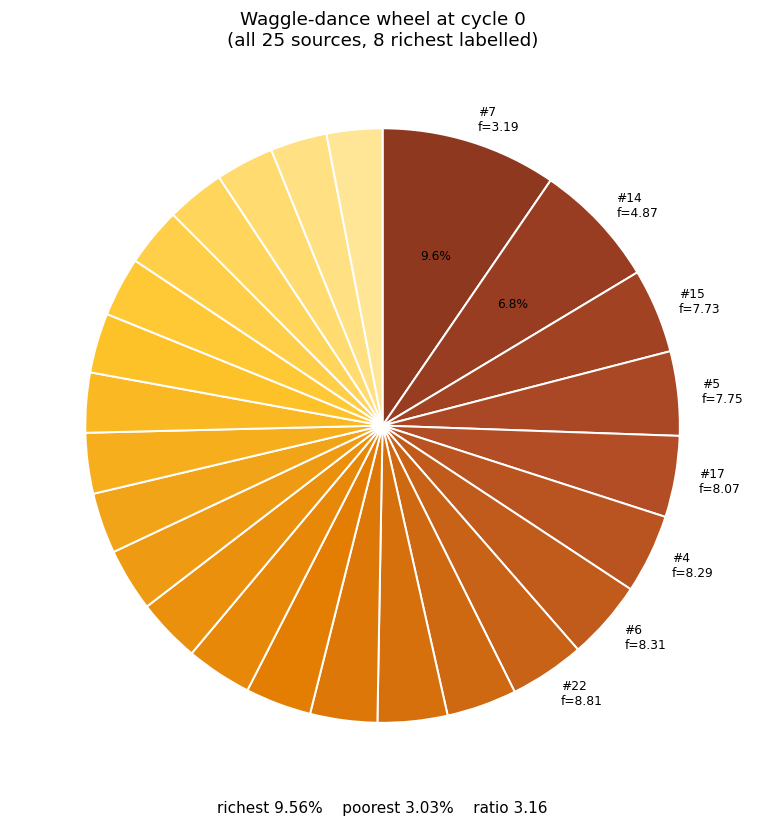

In [10]:
def plot_wheel(values, settings=SETTINGS, ax=None, n_labelled=8, title=None):
    """Pie chart of the onlooker selection probabilities."""
    probabilities = selection_probabilities(values, settings)
    order = np.argsort(probabilities)[::-1]                     # richest first
    shades = [HONEY(t) for t in np.linspace(0.30, 0.95, len(order))]
    labels = [(f"#{i}\nf={values[i]:.3g}" if rank < n_labelled else "")
              for rank, i in enumerate(order)]

    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 7.4))

    ax.pie(probabilities[order], labels=labels, colors=shades,
           startangle=90, counterclock=False, labeldistance=1.08,
           autopct=lambda pct: f"{pct:.1f}%" if pct >= 5.5 else "",
           textprops={"fontsize": 8}, wedgeprops={"edgecolor": "white", "linewidth": 1.3})
    ax.set_title(title or "Waggle-dance wheel - onlooker probability of each source")
    ax.text(0, -1.30, "richest %.2f%%    poorest %.2f%%    ratio %.2f"
            % (100 * probabilities.max(), 100 * probabilities.min(),
               probabilities.max() / probabilities.min()), ha="center", fontsize=10)
    return probabilities


fig, ax = plt.subplots(figsize=(7.6, 7.6))
probabilities0 = plot_wheel(initial_values, ax=ax,
                            title="Waggle-dance wheel at cycle 0\n(all 25 sources, 8 richest labelled)")
plt.tight_layout()
plt.show()

## 11. Inspect the strongest roulette candidates

- Rank the initial sources by objective value.
- Print nectar amount, wheel share, and expected number of onlooker visits.
- Also report the poorest source, to confirm that it keeps a non-zero chance.

In [11]:
fitness0 = to_fitness(initial_values, SETTINGS.fitness_kind)
ranking = np.argsort(initial_values)

print("Onlooker wheel at cycle 0 (best 8 food sources)")
print()
print(" rank   #        x1           x2        f(x1,x2)     nectar    % of wheel   expected visits")
print(" " + "-" * 96)
for rank, i in enumerate(ranking[:8], start=1):
    print(" %4d  %2d   %+9.5f   %+9.5f   %9.5f   %9.5f   %8.2f %%   %10.2f"
          % (rank, i, initial_sources[i, 0], initial_sources[i, 1],
             initial_values[i], fitness0[i], 100 * probabilities0[i],
             SETTINGS.n_onlookers * probabilities0[i]))
print(" " + "-" * 96)
poorest = ranking[-1]
print(" %-58s %9.5f   %8.2f %%   %10.2f"
      % ("whole colony (25 food sources)", fitness0.sum(), 100.0, SETTINGS.n_onlookers))
print()
print("The poorest source #%d has f = %.5f and owns only %.2f %% of the wheel -"
      % (poorest, initial_values[poorest], 100 * probabilities0[poorest]))
print("unlikely, but not impossible, to be visited by an onlooker.")

Onlooker wheel at cycle 0 (best 8 food sources)

 rank   #        x1           x2        f(x1,x2)     nectar    % of wheel   expected visits
 ------------------------------------------------------------------------------------------------
    1   7    +0.04548    +0.53497     3.18887     0.23873       9.56 %         2.39
    2  14    +1.29226    +0.14118     4.87413     0.17024       6.82 %         1.71
    3  15    -0.03127    -2.52485     7.72769     0.11458       4.59 %         1.15
    4   5    -1.96968    -2.21574     7.74967     0.11429       4.58 %         1.14
    5  17    +1.92032    -2.99393     8.06863     0.11027       4.42 %         1.10
    6   4    +2.97069    -0.32065     8.29202     0.10762       4.31 %         1.08
    7   6    -2.45130    -0.54924     8.31292     0.10738       4.30 %         1.08
    8  22    +1.39717    +2.41771     8.80900     0.10195       4.08 %         1.02
 ----------------------------------------------------------------------------------------

## 12. The neighbourhood search (slide 23)

This is the heart of ABC. Slide 23 gives

$$v_{ij} = x_{ij} + \varphi_{ij}\,(x_{ij} - x_{kj}),
\qquad \varphi_{ij} = \mathrm{rand}(-1,1), \qquad k \ne i .$$

- Only **one** randomly chosen coordinate $j$ changes. The other is copied unchanged.
- The step size is set by $|x_{ij} - x_{kj}|$, the gap to another bee.
- That gap shrinks automatically as the colony gathers, so **ABC needs no mutation-step
  schedule.** The GA version had to design one by hand.
- Afterwards the coordinate is clipped back into $[-5,+5]$.

In [12]:
def neighbour(sources, i, rng, settings):
    """v_ij = x_ij + phi_ij (x_ij - x_kj),  phi in (-1, 1),  k != i."""
    if settings.n_sources < 2:
        raise ValueError("ABC needs at least 2 food sources: the equation must "
                         "pick a partner k != i")

    candidate = sources[i].copy()

    partner = int(rng.integers(settings.n_sources - 1))      # k = rand(1, n), k != i
    if partner >= i:
        partner += 1

    dims = (np.arange(settings.n_dimensions) if settings.neighbour_kind == "all_dims"
            else [int(rng.integers(settings.n_dimensions))])

    for j in dims:
        phi = rng.uniform(-1.0, 1.0)
        candidate[j] = sources[i, j] + phi * (sources[i, j] - sources[partner, j])
        candidate[j] = min(max(candidate[j], settings.lower), settings.upper)   # stay in range

    return candidate


demo_rng = np.random.default_rng(11)
demo = np.array([[-1.5, -1.0], [2.0, 3.5], [-4.0, 2.5]])
demo_settings = replace(SETTINGS, colony_size=6)

print("source  x_0 = [-1.5, -1.0]       partners available: x_1, x_2")
print()
print("Six trial solutions generated from it:")
for _ in range(6):
    v = neighbour(demo, 0, demo_rng, demo_settings)
    moved = "x1" if abs(v[0] - demo[0, 0]) > 1e-12 else "x2"
    print("   v = [%+8.4f, %+8.4f]   (%s moved)   f = %.5f" % (v[0], v[1], moved, ackley(v)))
print()
print("Only one coordinate changes each time, and the size of the change is limited")
print("by the distance to the partner source.")

source  x_0 = [-1.5, -1.0]       partners available: x_1, x_2

Six trial solutions generated from it:
   v = [ -1.4949,  -1.0000]   (x1 moved)   f = 6.20972
   v = [ -1.5000,  +2.2992]   (x2 moved)   f = 8.63221
   v = [ -4.4975,  -1.0000]   (x1 moved)   f = 11.29370
   v = [ -3.3511,  -1.0000]   (x1 moved)   f = 9.29628
   v = [ -1.5000,  -1.8532]   (x2 moved)   f = 7.62227
   v = [ -1.4430,  -1.0000]   (x1 moved)   f = 6.08343

Only one coordinate changes each time, and the size of the change is limited
by the distance to the partner source.


## 13. Greedy selection

After a trial solution $v_i$ is evaluated, slide 23 says: *select the better solution comparing
$f(x_i)$ and $f(v_i)$.*

- If $v_i$ is better, it replaces $x_i$ and that source's trial counter resets to 0.
- If not, $x_i$ stays and the trial counter goes up by one.
- The trial counter is what the scout phase watches.

In [13]:
def greedy_select(sources, values, trials, i, candidate, candidate_value):
    """Keep the better of x_i and v_i; reset or raise the trial counter."""
    if candidate_value < values[i]:
        sources[i] = candidate
        values[i] = candidate_value
        trials[i] = 0                                   # improvement found
        return True
    trials[i] += 1                                      # no improvement
    return False


toy_sources = np.array([[2.0, 2.0]])
toy_values = ackley(toy_sources)
toy_trials = np.zeros(1, dtype=int)

print("start: x = [2.0, 2.0], f = %.5f, trial = %d" % (toy_values[0], toy_trials[0]))
for v in ([1.2, 2.0], [3.4, 2.0], [0.1, 2.0]):
    v = np.asarray(v, dtype=float)
    kept = greedy_select(toy_sources, toy_values, toy_trials, 0, v, float(ackley(v)))
    print("  try v = %-14s f = %8.5f  ->  %-8s  now x = %-16s trial = %d"
          % (str(list(v)), ackley(v), "ACCEPT" if kept else "reject",
             str(np.round(toy_sources[0], 4).tolist()), toy_trials[0]))

start: x = [2.0, 2.0], f = 6.59360, trial = 0
  try v = [np.float64(1.2), np.float64(2.0)] f =  6.41343  ->  ACCEPT    now x = [1.2, 2.0]       trial = 0
  try v = [np.float64(3.4), np.float64(2.0)] f = 10.16935  ->  reject    now x = [1.2, 2.0]       trial = 1
  try v = [np.float64(0.1), np.float64(2.0)] f =  5.18012  ->  ACCEPT    now x = [0.1, 2.0]       trial = 0


## 14. The employed bee phase

Each of the 25 employed bees owns one food source and tries exactly one trial solution next
to it, then greedy-selects. This is **exploitation**: careful local improvement.

In [14]:
def employed_bee_phase(sources, values, trials, rng, settings):
    """Every employed bee tries one new point next to the source it owns."""
    improved = 0
    for i in range(settings.n_sources):
        candidate = neighbour(sources, i, rng, settings)
        improved += greedy_select(sources, values, trials, i,
                                  candidate, float(ackley(candidate)))
    return improved


demo_rng = np.random.default_rng(SETTINGS.seed + 1)
sources = initial_sources.copy()
values = initial_values.copy()
trials = initial_trials.copy()

n_improved = employed_bee_phase(sources, values, trials, demo_rng, SETTINGS)

print("employed bees that found something better : %d of %d"
      % (n_improved, SETTINGS.n_sources))
print("sources whose trial counter went up       : %d" % int((trials > 0).sum()))
print()
print("                  best        mean       worst")
print("before      %10.5f  %10.5f  %10.5f"
      % (initial_values.min(), initial_values.mean(), initial_values.max()))
print("after       %10.5f  %10.5f  %10.5f"
      % (values.min(), values.mean(), values.max()))
print()
print("No source can ever get worse: greedy selection only accepts improvements.")

employed bees that found something better : 13 of 25
sources whose trial counter went up       : 12

                  best        mean       worst
before         3.18887     9.71712    12.22943
after          2.89666     8.81964    11.62008

No source can ever get worse: greedy selection only accepts improvements.


## 15. The onlooker bee phase

The 25 onlookers watch the waggle dance and choose which source to visit with the roulette
wheel from section 9. A rich source can be chosen several times; a poor source may be skipped.
Each chosen source then gets the **same** neighbourhood search and greedy selection.

This is where the extra search effort goes: the colony performs 25 more trials per cycle, and
it concentrates them on the promising sources.

In [15]:
def onlooker_bee_phase(sources, values, trials, rng, settings):
    """Onlookers watch the waggle dance and pick sources by roulette wheel."""
    probabilities = selection_probabilities(values, settings)
    picks = roulette_wheel(probabilities, rng, settings.n_onlookers)
    improved = 0
    for i in picks:
        i = int(i)
        candidate = neighbour(sources, i, rng, settings)
        improved += greedy_select(sources, values, trials, i,
                                  candidate, float(ackley(candidate)))
    return improved, probabilities, picks


before = values.copy()
n_improved, probs, picks = onlooker_bee_phase(sources, values, trials, demo_rng, SETTINGS)
counts = np.bincount(picks, minlength=SETTINGS.n_sources)
order = np.argsort(before)

print("onlooker visits that found something better : %d of %d"
      % (n_improved, SETTINGS.n_onlookers))
print()
print("  rank   source   f before     wheel share   visits received")
print("  " + "-" * 60)
for rank, i in enumerate(order[:5], start=1):
    print("  %4d   %5d   %10.5f   %8.2f %%   %12d"
          % (rank, i, before[i], 100 * probs[i], counts[i]))
print("  ...")
for rank, i in enumerate(order[-2:], start=len(order) - 1):
    print("  %4d   %5d   %10.5f   %8.2f %%   %12d"
          % (rank, i, before[i], 100 * probs[i], counts[i]))
print("  " + "-" * 60)
print("  total visits handed out: %d" % counts.sum())
print()
print("best after one full cycle of employed + onlooker bees : %.6f" % values.min())

onlooker visits that found something better : 2 of 25

  rank   source   f before     wheel share   visits received
  ------------------------------------------------------------
     1       7      2.89666       9.17 %              3
     2      12      3.33067       8.26 %              3
     3      14      4.87413       6.09 %              3
     4      21      6.05833       5.07 %              1
     5      15      7.72769       4.10 %              1
  ...
    24       3     11.53467       2.85 %              0
    25      16     11.62008       2.83 %              1
  ------------------------------------------------------------
  total visits handed out: 25

best after one full cycle of employed + onlooker bees : 2.700077


## 16. The scout bee phase (slide 30)

> *"providing that a position can not be improved further through a predetermined number of
> cycles, which is called `limit`, then that food source is assumed to be abandoned."*

The abandoned source is replaced using the **initialisation equation from slide 21**. That is
ABC's escape route from a local minimum. We allow at most one scout per cycle.

In [16]:
def scout_bee_phase(sources, values, trials, rng, settings):
    """A source that has not improved for `limit` tries is abandoned."""
    scouted = []
    for _ in range(settings.n_scouts_per_cycle):
        worst = int(np.argmax(trials))
        if trials[worst] <= settings.limit:
            break                                       # nothing is stuck yet
        sources[worst] = settings.lower + rng.random(settings.n_dimensions) * (
            settings.upper - settings.lower)
        values[worst] = float(ackley(sources[worst]))
        trials[worst] = 0
        scouted.append(worst)
    return scouted


print("largest trial counter right now : %d   (limit = %d)"
      % (trials.max(), SETTINGS.limit))
print("scouts sent                     :", scout_bee_phase(sources, values, trials,
                                                           demo_rng, SETTINGS))
print()

# force the situation so the mechanism can be seen
stuck_sources = initial_sources.copy()
stuck_values = initial_values.copy()
stuck_trials = np.zeros(SETTINGS.n_sources, dtype=int)
stuck_trials[7] = SETTINGS.limit + 1

print("Now pretend source #7 has failed %d times in a row:" % (SETTINGS.limit + 1))
print("  before :  x = %-28s f = %9.5f" % (np.round(stuck_sources[7], 5).tolist(),
                                           stuck_values[7]))
sent = scout_bee_phase(stuck_sources, stuck_values, stuck_trials,
                       np.random.default_rng(4), SETTINGS)
print("  scout replaced source %d" % sent[0])
print("  after  :  x = %-28s f = %9.5f" % (np.round(stuck_sources[7], 5).tolist(),
                                           stuck_values[7]))
print("  trial counter reset to %d" % stuck_trials[7])
print()
print("The new source may well be worse. That is the point: it buys a fresh look")
print("at a different part of the search space.")

largest trial counter right now : 4   (limit = 50)
scouts sent                     : []

Now pretend source #7 has failed 51 times in a row:
  before :  x = [0.04548, 0.53497]           f =   3.18887
  scout replaced source 7
  after  :  x = [4.43056, 0.11328]           f =  11.10393
  trial counter reset to 0

The new source may well be worse. That is the point: it buys a fresh look
at a different part of the search space.


## 17. The complete ABC loop (slide 18)

> Step 1: assign control parameters
> Step 2: initialize solutions
> Step 3: repeat until stopping criteria is met
>   - send the employed bees and calculate fitness
>   - send the onlookers and calculate fitness
>   - send the scout bees and calculate fitness
>   - **memorize the best solution**
> Step 4: stop

One detail matters: we memorise the best solution **before** the scout runs, so a scout can
never destroy the best answer found so far. That is ABC's version of elitism.

In [17]:
def run_abc(settings=SETTINGS, verbose=True, snapshot_at=()):
    """Run the complete Artificial Bee Colony and return everything worth reporting."""
    rng = np.random.default_rng(settings.seed)

    sources = create_sources(rng, settings)                      # Step 2
    values = ackley(sources)
    trials = np.zeros(settings.n_sources, dtype=int)

    best_index = int(np.argmin(values))
    best_solution = sources[best_index].copy()                   # memorise the best
    best_value = float(values[best_index])
    best_cycle = 0

    history = {key: [] for key in
               ("cycle", "best", "mean", "worst", "best_x1", "best_x2", "spread",
                "max_trial", "scouts", "distinct", "employed_improved",
                "onlooker_improved", "wheel_ratio")}
    snapshots, scout_events = {}, []
    stagnation = 0
    stop_reason = f"reached the maximum of {settings.max_cycles} cycles"

    # Count the Ackley calls for real. Step 2 already tasted every initial source.
    evaluations = settings.n_sources

    for cycle in range(settings.max_cycles + 1):                 # Step 3
        history["cycle"].append(cycle)
        history["best"].append(best_value)
        history["mean"].append(float(values.mean()))
        history["worst"].append(float(values.max()))
        history["best_x1"].append(float(best_solution[0]))
        history["best_x2"].append(float(best_solution[1]))
        history["spread"].append(float(np.mean(np.std(sources, axis=0))))
        history["max_trial"].append(int(trials.max()))
        history["distinct"].append(int(len(np.unique(sources, axis=0))))
        wheel = selection_probabilities(values, settings)
        history["wheel_ratio"].append(float(wheel.max() / wheel.min()))
        if cycle in snapshot_at:
            snapshots[cycle] = (sources.copy(), values.copy(), trials.copy())

        # --- stopping criteria ---------------------------------------
        if cycle == settings.max_cycles or stagnation >= settings.patience:
            if stagnation >= settings.patience:
                stop_reason = (f"improvement stayed below {settings.tolerance:g} "
                               f"for {settings.patience} cycles in a row")
            for key in ("scouts", "employed_improved", "onlooker_improved"):
                history[key].append(0)
            break

        previous_best = best_value

        n_employed = employed_bee_phase(sources, values, trials, rng, settings)
        evaluations += settings.n_sources            # one trial point per employed bee
        if settings.use_onlookers:
            n_onlooker, _, _ = onlooker_bee_phase(sources, values, trials, rng, settings)
            evaluations += settings.n_onlookers      # one trial point per onlooker visit
        else:
            n_onlooker = 0

        # memorise the best BEFORE the scout can overwrite it
        cycle_best = int(np.argmin(values))
        if values[cycle_best] < best_value:
            best_value = float(values[cycle_best])
            best_solution = sources[cycle_best].copy()
            best_cycle = cycle + 1

        scouted = (scout_bee_phase(sources, values, trials, rng, settings)
                   if settings.use_scouts else [])
        evaluations += len(scouted)                  # a scout only costs when it flies
        if scouted:
            scout_events.append((cycle + 1, scouted))

        history["scouts"].append(len(scouted))
        history["employed_improved"].append(n_employed)
        history["onlooker_improved"].append(n_onlooker)

        stagnation = stagnation + 1 if (previous_best - best_value) < settings.tolerance else 0

    budget = settings.n_sources + history["cycle"][-1] * (
        settings.n_sources + settings.n_onlookers + settings.n_scouts_per_cycle)
    result = {
        "best_solution": best_solution,
        "best_value": best_value,
        "best_cycle": best_cycle,
        "cycles_run": history["cycle"][-1],
        "stop_reason": stop_reason,
        "history": {key: np.asarray(value) for key, value in history.items()},
        "sources": sources,
        "values": values,
        "trials": trials,
        "snapshots": snapshots,
        "scout_events": scout_events,
        "settings": settings,
        "evaluations": evaluations,        # Ackley calls that really happened
        "evaluation_budget": budget,       # worst case, if every scout slot were used
    }

    if verbose:
        print("stopped because : " + stop_reason)
        print("cycles run      : %d" % result["cycles_run"])
        print("best found at   : cycle %d" % best_cycle)
        print("best x1         : %+.14f" % best_solution[0])
        print("best x2         : %+.14f" % best_solution[1])
        print("best f(x1, x2)  : %.12e" % best_value)

    return result


print("run_abc is ready.")

run_abc is ready.


## 18. Run the main experiment

- Use random seed 7 so the main result can be repeated.
- Save the colony at selected cycles for the plots further down.
- Store the result and its history for the rest of the analysis.

In [18]:
SNAPSHOT_CYCLES = (0, 3, 8, 20, 50, 100)

result = run_abc(SETTINGS, verbose=True, snapshot_at=SNAPSHOT_CYCLES)
history = result["history"]

stopped because : reached the maximum of 100 cycles
cycles run      : 100
best found at   : cycle 99
best x1         : +0.00000000000023
best x2         : -0.00000000000004
best f(x1, x2)  : 6.541434061091e-13


## 19. Report the final solution

- Print the best coordinates, function value, and the cycle it was found at.
- Compare the result with the theoretical optimum $(0,0)$.
- Report the coordinate error, Euclidean distance, and the evaluation budget used.

In [19]:
best_x1, best_x2 = result["best_solution"]
best_f = result["best_value"]

error_x1, error_x2 = abs(best_x1), abs(best_x2)
distance = float(np.linalg.norm(result["best_solution"] - GLOBAL_OPTIMUM))
error_f = abs(best_f)


def decimal_places(error):
    """How many decimal places of the answer are correct."""
    return int(np.floor(-np.log10(error))) if error > 0 else float("inf")


rule = "=" * 70
print(rule)
print(" FINAL RESULT - 2-D Ackley minimisation by Artificial Bee Colony")
print(rule)
print(" Best x1                        : %+.14f" % best_x1)
print(" Best x2                        : %+.14f" % best_x2)
print(" Best Ackley value f(x1, x2)    : %.12e" % best_f)
print(" Found at                       : cycle %d  (of %d run)"
      % (result["best_cycle"], result["cycles_run"]))
print(" Stopping reason                : %s" % result["stop_reason"])
print(rule)
print(" PRECISION AGAINST THE TRUE OPTIMUM   x* = (0, 0),  f(x*) = 0")
print(rule)
print(" |x1 - 0|                       : %.3e   (%d correct decimal places)"
      % (error_x1, decimal_places(error_x1)))
print(" |x2 - 0|                       : %.3e   (%d correct decimal places)"
      % (error_x2, decimal_places(error_x2)))
print(" Euclidean distance to (0, 0)   : %.3e" % distance)
print(" |f(x1, x2) - 0|                : %.3e   (%d correct decimal places)"
      % (error_f, decimal_places(error_f)))
print(rule)
print(" Ackley evaluations used        : %d   <- actual calls" % result["evaluations"])
print("   = %d initial + %d cycles x (%d employed + %d onlooker) + %d scout call(s)"
      % (SETTINGS.n_sources, result["cycles_run"], SETTINGS.n_sources,
         SETTINGS.n_onlookers, int(np.sum(history["scouts"]))))
print(" Worst-case budget              : %d   (if a scout flew every cycle)"
      % result["evaluation_budget"])
print(" Scouts actually sent           : %d" % int(np.sum(history["scouts"])))
print(rule)

 FINAL RESULT - 2-D Ackley minimisation by Artificial Bee Colony
 Best x1                        : +0.00000000000023
 Best x2                        : -0.00000000000004
 Best Ackley value f(x1, x2)    : 6.541434061091e-13
 Found at                       : cycle 99  (of 100 run)
 Stopping reason                : reached the maximum of 100 cycles
 PRECISION AGAINST THE TRUE OPTIMUM   x* = (0, 0),  f(x*) = 0
 |x1 - 0|                       : 2.278e-13   (12 correct decimal places)
 |x2 - 0|                       : 3.938e-14   (13 correct decimal places)
 Euclidean distance to (0, 0)   : 2.312e-13
 |f(x1, x2) - 0|                : 6.541e-13   (12 correct decimal places)
 Ackley evaluations used        : 5025   <- actual calls
   = 25 initial + 100 cycles x (25 employed + 25 onlooker) + 0 scout call(s)
 Worst-case budget              : 5125   (if a scout flew every cycle)
 Scouts actually sent           : 0


## 20. Convergence, and who does the work

- The left plot tracks best, mean and worst nectar on a log scale.
- The right plot counts how many employed-bee and onlooker visits improved a source, and
  follows the largest trial counter against the `limit`.
- Watch the brown trial line: it never reaches the limit, so no scout was ever needed.

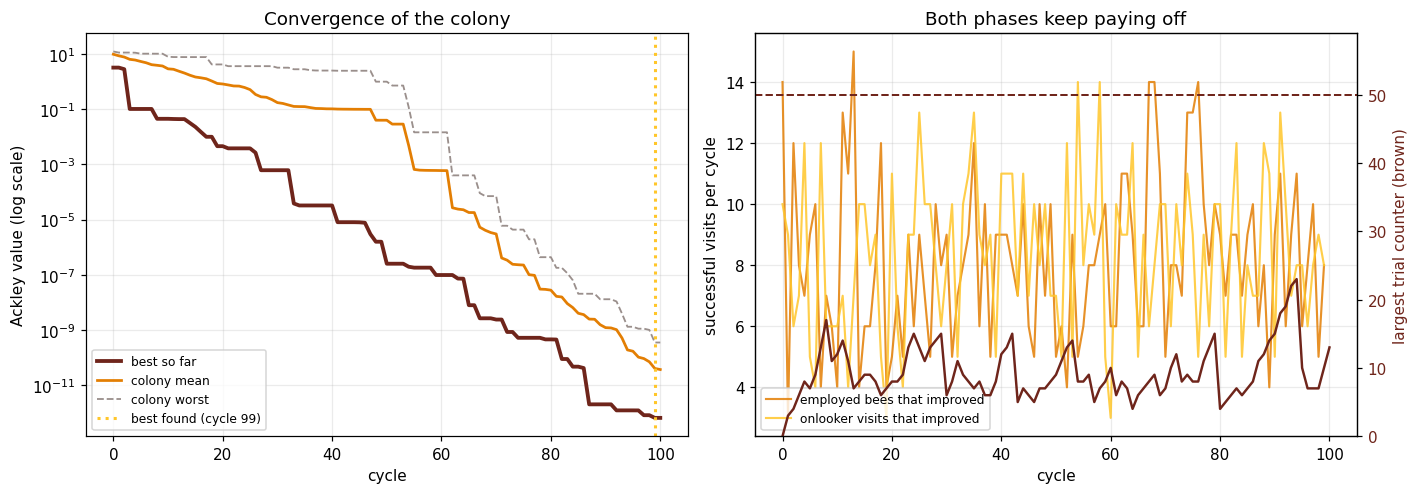

largest trial counter over the whole run : 23   (limit = 50)
scouts sent                              : 0
employed-bee successes, total            : 816
onlooker successes, total                : 835


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
floor = 1e-17

ax = axes[0]
ax.semilogy(history["cycle"], np.maximum(history["best"], floor),
            color=BROWN, linewidth=2.5, label="best so far")
ax.semilogy(history["cycle"], np.maximum(history["mean"], floor),
            color=DEEP, linewidth=1.8, label="colony mean")
ax.semilogy(history["cycle"], np.maximum(history["worst"], floor),
            color=GREY, linewidth=1.2, linestyle="--", label="colony worst")
ax.axvline(result["best_cycle"], color=AMBER, linestyle=":", linewidth=2.0,
           label=f"best found (cycle {result['best_cycle']})")
ax.set_xlabel("cycle"); ax.set_ylabel("Ackley value (log scale)")
ax.set_title("Convergence of the colony")
ax.legend(fontsize=8)

ax = axes[1]
cycles = history["cycle"][:-1]
ax.plot(cycles, history["employed_improved"][:-1], color=DEEP, linewidth=1.4,
        alpha=0.85, label="employed bees that improved")
ax.plot(cycles, history["onlooker_improved"][:-1], color=AMBER, linewidth=1.4,
        alpha=0.85, label="onlooker visits that improved")
ax.set_xlabel("cycle"); ax.set_ylabel("successful visits per cycle")
ax.set_title("Both phases keep paying off")
ax.legend(fontsize=8, loc="lower left")

twin = ax.twinx()
twin.plot(history["cycle"], history["max_trial"], color=BROWN, linewidth=1.6)
twin.axhline(SETTINGS.limit, color=BROWN, linestyle="--", linewidth=1.3)
twin.set_ylim(0, SETTINGS.limit * 1.18)
twin.set_ylabel("largest trial counter (brown)", color=BROWN)
twin.tick_params(axis="y", labelcolor=BROWN)
twin.grid(False)

plt.tight_layout()
plt.show()

print("largest trial counter over the whole run : %d   (limit = %d)"
      % (history["max_trial"].max(), SETTINGS.limit))
print("scouts sent                              : %d" % int(np.sum(history["scouts"])))
print("employed-bee successes, total            : %d" % int(np.sum(history["employed_improved"])))
print("onlooker successes, total                : %d" % int(np.sum(history["onlooker_improved"])))

## 21. Print selected cycles

- Show the first few cycles and then every tenth cycle.
- The best column can never increase, because the best solution is memorised.

In [21]:
rows = [c for c in history["cycle"] if c <= 5 or c % 10 == 0]

print("  cyc        best f        mean f       worst f      best x1       best x2    maxtrial  wheel")
print("  " + "-" * 102)
for c in rows:
    i = int(np.where(history["cycle"] == c)[0][0])
    print("  %3d   %12.6e  %12.6e  %12.4e  %+11.3e  %+11.3e   %6d  %5.2f"
          % (c, history["best"][i], history["mean"][i], history["worst"][i],
             history["best_x1"][i], history["best_x2"][i],
             history["max_trial"][i], history["wheel_ratio"][i]))
print("  " + "-" * 102)
print("  The best column never increases: the best solution is memorised every cycle.")

  cyc        best f        mean f       worst f      best x1       best x2    maxtrial  wheel
  ------------------------------------------------------------------------------------------------------
    0   3.188874e+00  9.717116e+00    1.2229e+01   +4.548e-02   +5.350e-01        0   3.16
    1   3.188874e+00  8.525875e+00    1.1180e+01   +4.548e-02   +5.350e-01        3   2.91
    2   2.792381e+00  7.686203e+00    1.1180e+01   -1.012e+00   -6.704e-02        4   3.21
    3   1.013042e-01  6.357930e+00    1.1180e+01   +7.506e-03   +2.730e-02        6  11.06
    4   1.013042e-01  5.996372e+00    1.1027e+01   +7.506e-03   +2.730e-02        8  10.92
    5   1.013042e-01  5.330468e+00    1.0179e+01   +7.506e-03   +2.730e-02        7  10.15
   10   4.457535e-02  2.878125e+00    7.8820e+00   +6.083e-03   +1.254e-02       12   8.50
   20   4.542022e-03  8.126608e-01    4.1504e+00   +1.582e-03   +3.328e-05        8   5.13
   30   6.117318e-04  1.718889e-01    3.1690e+00   +2.158e-04   -4.564e-0

## 22. The step size shrinks on its own

The GA notebook needed an adaptive rule, $\sigma = \mathrm{clip}(f_{best}/4,\,10^{-12},\,2)$, to
stop the mutation step from being too large near the end.

ABC gets the same effect for free. The step is $\varphi_{ij}(x_{ij}-x_{kj})$, so it is bounded by
the distance between two bees. As the colony contracts, that distance contracts with it.

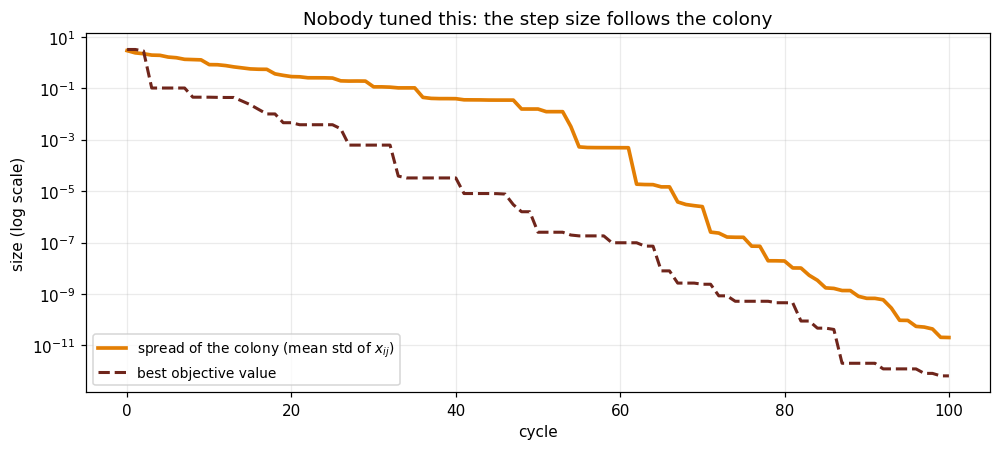

cycle   0 :  colony spread = 2.879e+00   best f = 3.189e+00
cycle  20 :  colony spread = 2.818e-01   best f = 4.542e-03
cycle  50 :  colony spread = 1.546e-02   best f = 2.510e-07
cycle 100 :  colony spread = 2.026e-11   best f = 6.541e-13


In [22]:
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.semilogy(history["cycle"], np.maximum(history["spread"], 1e-17),
            color=DEEP, linewidth=2.4, label=r"spread of the colony (mean std of $x_{ij}$)")
ax.semilogy(history["cycle"], np.maximum(history["best"], 1e-17),
            color=BROWN, linewidth=2.0, linestyle="--", label="best objective value")
ax.set_xlabel("cycle"); ax.set_ylabel("size (log scale)")
ax.set_title("Nobody tuned this: the step size follows the colony")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

for c in (0, 20, 50, 100):
    i = int(np.where(history["cycle"] == c)[0][0])
    print("cycle %3d :  colony spread = %.3e   best f = %.3e"
          % (c, history["spread"][i], history["best"][i]))

## 23. Plot the best-solution path

- Keep only the cycles that improved the best-so-far solution.
- Plot those points on a wide view and a zoomed view near the origin.
- The path shows exploration first and fine adjustment later.

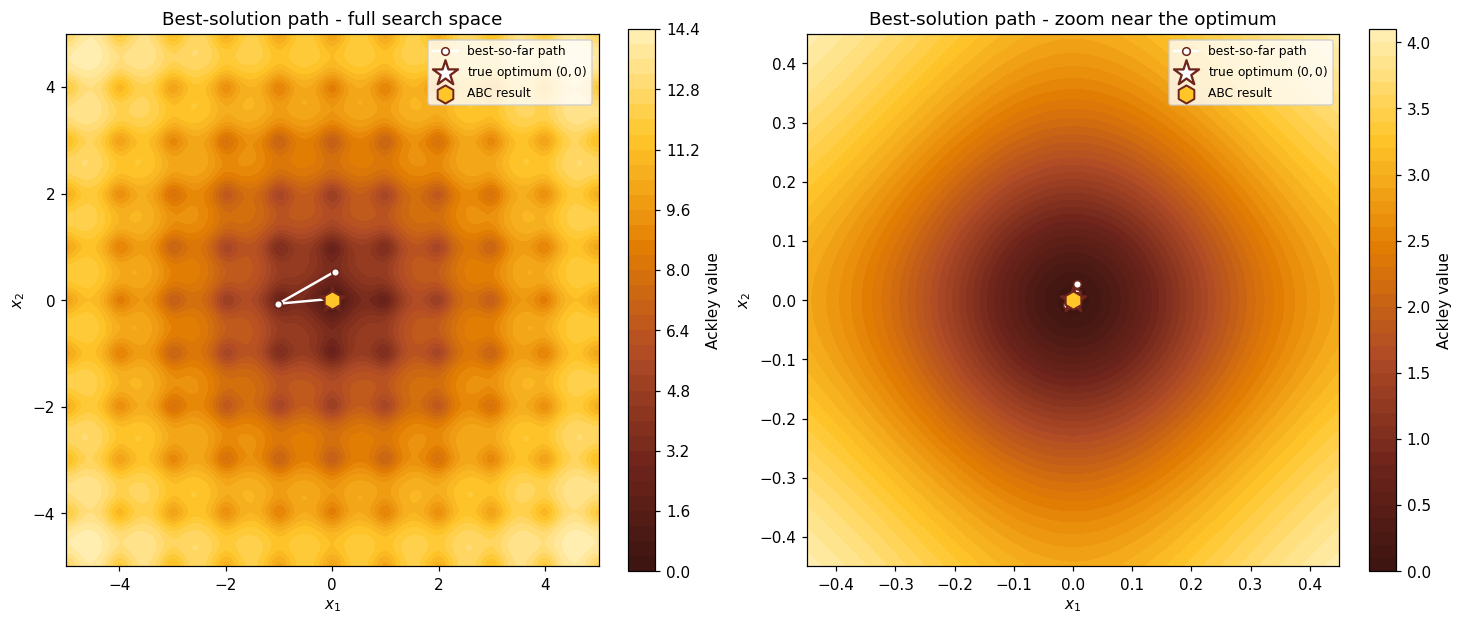

The best solution was improved 43 times during the run.


In [23]:
path = np.column_stack([history["best_x1"], history["best_x2"]])
changed = np.r_[True, np.any(np.diff(path, axis=0) != 0, axis=1)]
improvements = path[changed]

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.8))

for ax, limit, label in [(axes[0], 5.0, "full search space"),
                         (axes[1], 0.45, "zoom near the optimum")]:
    g = np.linspace(-limit, limit, 400)
    A, B = np.meshgrid(g, g)
    filled = ax.contourf(A, B, ackley(np.stack([A, B], axis=-1)), levels=45, cmap=HONEY)
    fig.colorbar(filled, ax=ax, fraction=0.046, label="Ackley value")

    inside = np.all(np.abs(improvements) <= limit, axis=1)
    ax.plot(improvements[inside, 0], improvements[inside, 1], "o-",
            color="white", markeredgecolor=BROWN, markersize=5, linewidth=1.6,
            label="best-so-far path")
    ax.scatter(0, 0, marker="*", s=300, color="white", edgecolor=BROWN, linewidth=1.5,
               zorder=6, label="true optimum $(0,0)$")
    ax.scatter(best_x1, best_x2, marker="h", s=140, color=AMBER, edgecolor=BROWN,
               linewidth=1.3, zorder=6, label="ABC result")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(f"Best-solution path - {label}")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("The best solution was improved %d times during the run." % (len(improvements) - 1))

## 24. Plot the colony at six moments

- Display all 25 food sources at six stages of the run.
- **Read the axis labels**: each panel is zoomed in further than the last.
- The sequence shows the colony contracting onto the central valley.

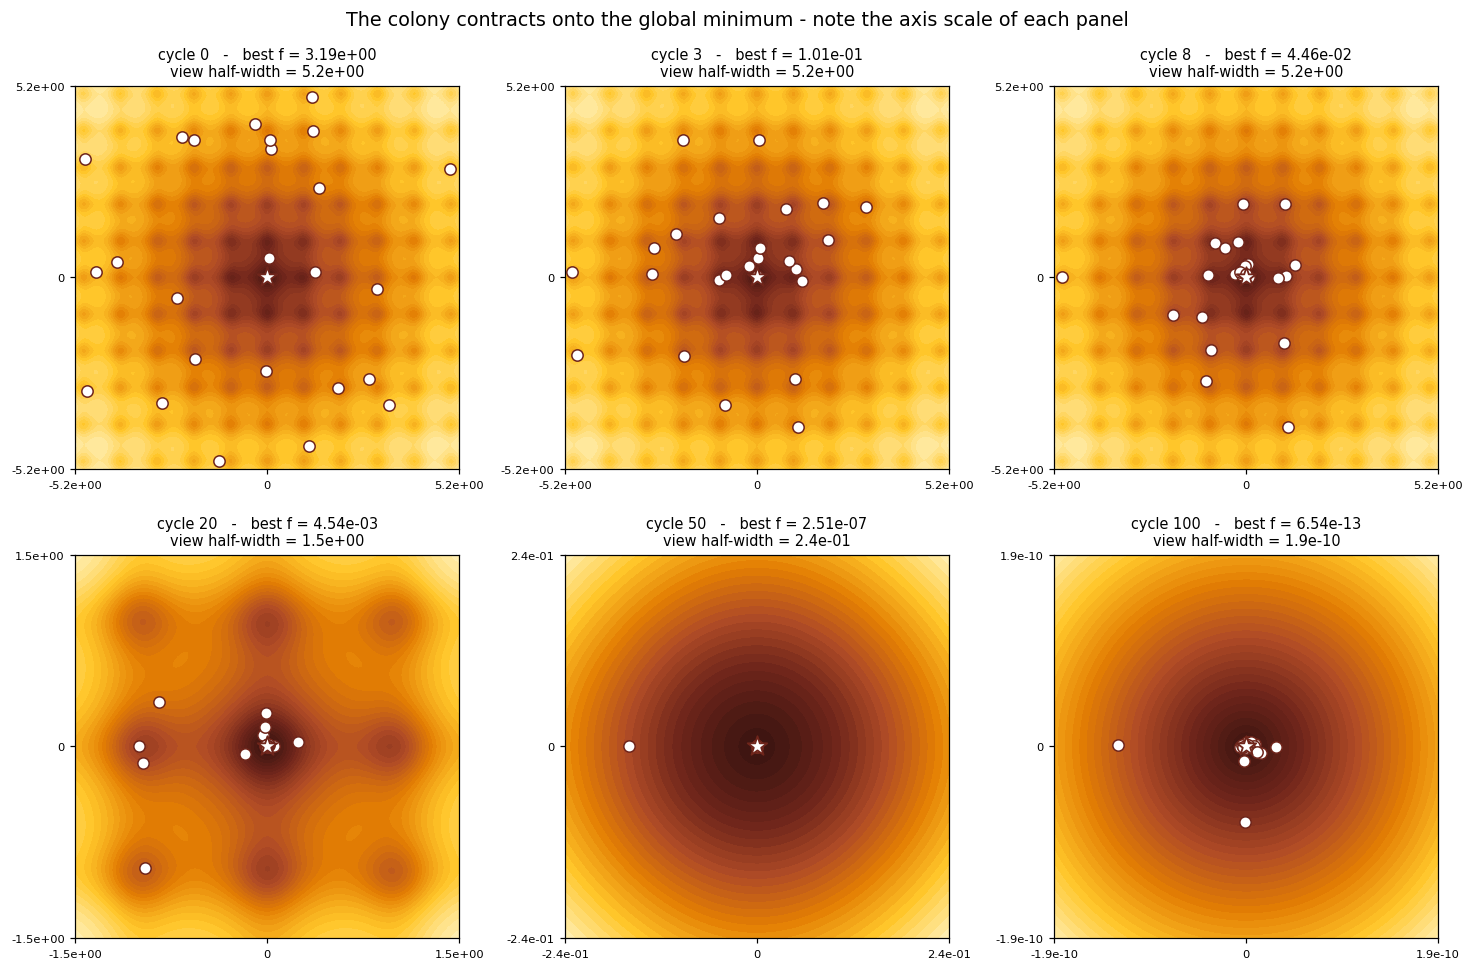

  cyc   distinct   spread (mean std)   largest trial
    0       25       2.879171e+00            0
    3       25       1.928433e+00            6
    8       25       1.291151e+00           17
   20       25       2.817945e-01            8
   50       25       1.545641e-02            9
  100       25       2.026228e-11           13


In [24]:
available = [c for c in SNAPSHOT_CYCLES if c in result["snapshots"]]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 9.0))

for ax, cycle in zip(axes.ravel(), available):
    snapshot, snap_values, _ = result["snapshots"][cycle]

    limit = max(min(1.5 * np.abs(snapshot).max(), 5.2), 1e-13)
    g = np.linspace(-limit, limit, 200)
    A, B = np.meshgrid(g, g)
    ax.contourf(A, B, ackley(np.stack([A, B], axis=-1)), levels=40, cmap=HONEY)

    ax.scatter(snapshot[:, 0], snapshot[:, 1], s=55, color="white",
               edgecolor=BROWN, linewidth=1.0, zorder=4)
    ax.scatter(0, 0, marker="*", s=180, color="white", edgecolor=BROWN,
               linewidth=1.2, zorder=5)
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit); ax.set_aspect("equal")
    ax.set_title("cycle %d   -   best f = %.2e\nview half-width = %.1e"
                 % (cycle, snap_values.min(), limit), fontsize=9.5)
    ax.set_xticks([-limit, 0, limit])
    ax.set_xticklabels([f"{-limit:.1e}", "0", f"{limit:.1e}"], fontsize=7.5)
    ax.set_yticks([-limit, 0, limit])
    ax.set_yticklabels([f"{-limit:.1e}", "0", f"{limit:.1e}"], fontsize=7.5)

for ax in axes.ravel()[len(available):]:
    ax.axis("off")

fig.suptitle("The colony contracts onto the global minimum - note the axis scale of each panel",
             fontsize=12.5)
plt.tight_layout()
plt.show()

print("  cyc   distinct   spread (mean std)   largest trial")
for cycle in available:
    snapshot, _, snap_trials = result["snapshots"][cycle]
    print("  %3d   %6d       %.6e        %5d"
          % (cycle, len(np.unique(snapshot, axis=0)),
             np.mean(np.std(snapshot, axis=0)), snap_trials.max()))

## 25. What happens to the waggle-dance wheel

Here is something the slides do not mention, and it is worth knowing.

The nectar rule $fit = 1/(1+f)$ is squeezed into $(0,1]$. Once every source has $f$ below about
$10^{-3}$, **every** nectar value rounds to 1, so every slice of the wheel becomes $1/25 = 4\%$
and the onlookers are effectively choosing at random.

Section 27 measures whether this actually costs anything. (The answer is interesting.)

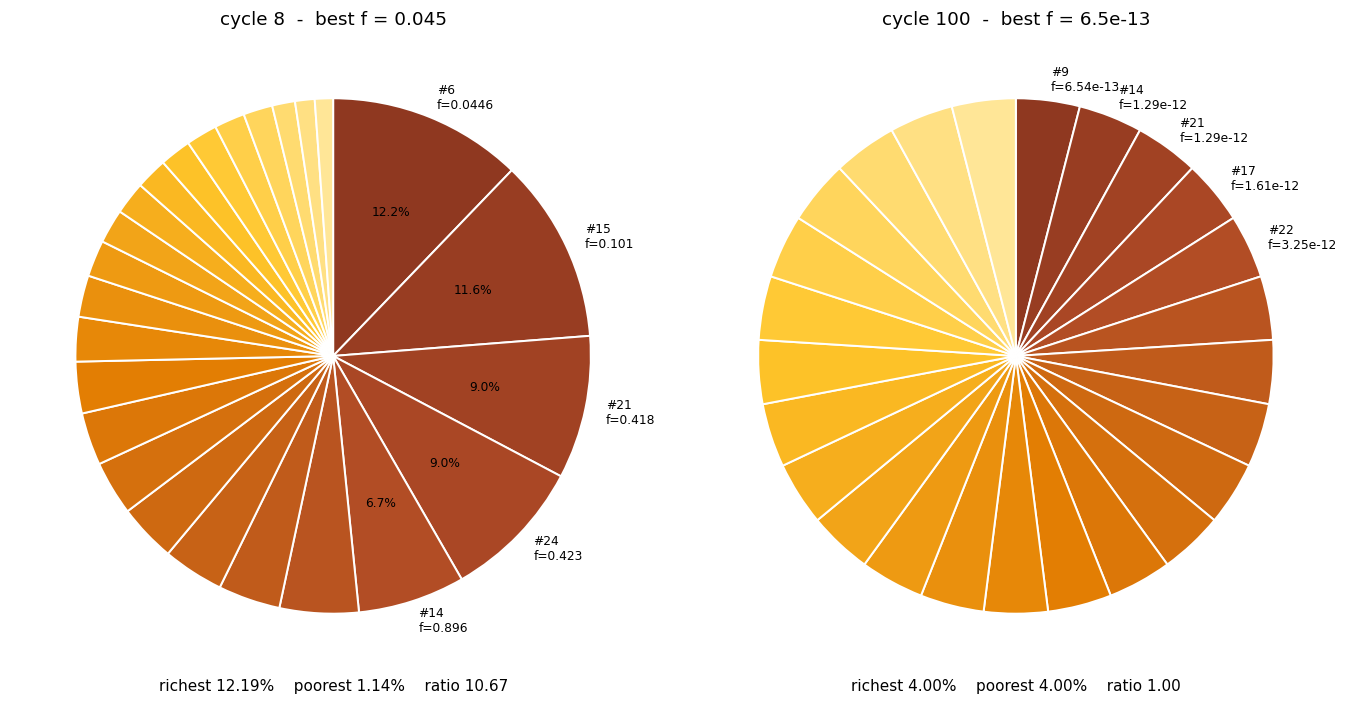

  cycle   best f       worst f      richest slice   poorest slice   ratio
  ------------------------------------------------------------------------
      0    3.189e+00   1.223e+01        9.564 %        3.028 %     3.16
      3    1.013e-01   1.118e+01       20.000 %        1.808 %    11.06
      8    4.458e-02   1.015e+01       12.191 %        1.142 %    10.67
     20    4.542e-03   4.150e+00        5.357 %        1.045 %     5.13
     50    2.510e-07   9.866e-01        4.082 %        2.055 %     1.99
    100    6.541e-13   3.513e-10        4.000 %        4.000 %     1.00
  ------------------------------------------------------------------------
  The wheel is completely uniform from cycle 62 onwards.


In [25]:
# Cycle 50 is NOT uniform yet (its slices still run 2.05 % - 4.08 %).
# The wheel only flattens completely at cycle 62, so the "after" pie uses cycle 100.
early = result["snapshots"][8][1]
late = result["snapshots"][100][1]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 6.2))
plot_wheel(early, ax=axes[0], n_labelled=5, title="cycle 8  -  best f = %.2g" % early.min())
plot_wheel(late, ax=axes[1], n_labelled=5, title="cycle 100  -  best f = %.2g" % late.min())
plt.tight_layout()
plt.show()

print("  cycle   best f       worst f      richest slice   poorest slice   ratio")
print("  " + "-" * 72)
for cycle in available:
    _, snap_values, _ = result["snapshots"][cycle]
    p = selection_probabilities(snap_values, SETTINGS)
    print("  %5d   %10.3e  %10.3e   %10.3f %%   %10.3f %%   %6.2f"
          % (cycle, snap_values.min(), snap_values.max(),
             100 * p.max(), 100 * p.min(), p.max() / p.min()))
print("  " + "-" * 72)

flat = int(np.argmax(history["wheel_ratio"] < 1.001))
print("  The wheel is completely uniform from cycle %d onwards." % flat)

## 26. Correctness checks

- Confirm the objective, colony shape, bounds, memorised best, and trial counters.
- Check that onlooker probabilities are positive and sum to one.
- Rerun the seeded ABC to confirm that the result is reproducible.

In [26]:
assert abs(ackley([0.0, 0.0])) < 1e-12, "f(0,0) must be 0"

assert result["sources"].shape == (SETTINGS.n_sources, SETTINGS.n_dimensions), \
    "the colony must stay 25 x 2"
assert np.all(result["sources"] >= SETTINGS.lower), "a coordinate fell below -5"
assert np.all(result["sources"] <= SETTINGS.upper), "a coordinate rose above +5"
assert np.all(np.isfinite(result["values"])), "an objective value is not finite"
assert np.allclose(ackley(result["sources"]), result["values"]), \
    "a stored value does not match its source"

assert np.all(np.diff(history["best"]) <= 1e-15), "the memorised best got worse"
assert np.isclose(ackley(result["best_solution"]), result["best_value"]), \
    "the reported best value does not match the reported source"
assert result["best_value"] <= history["best"][0], "no improvement over cycle 0"

# NOTE: trials <= limit is NOT guaranteed in general. Only one scout flies per
# cycle, so if two sources pass the limit at the same time, the second has to
# wait. What IS guaranteed is that a source past the limit gets replaced soon.
# In this run no counter even reached the limit, so we assert the stronger fact
# and print the general one.
assert result["trials"].max() <= SETTINGS.limit + SETTINGS.n_sources, (
    "a trial counter ran far past the limit")

p_check = selection_probabilities(result["values"], SETTINGS)
assert np.isclose(p_check.sum(), 1.0), "onlooker probabilities must sum to 1"
assert np.all(p_check > 0), "every source must keep a non-zero chance"

assert np.isclose(run_abc(SETTINGS, verbose=False)["best_value"], result["best_value"]), \
    "the seeded run is not reproducible"

print("All correctness checks passed.")
print("  - f(0,0) = 0")
print("  - the colony stayed %d x %d and inside [-5, +5]"
      % (SETTINGS.n_sources, SETTINGS.n_dimensions))
print("  - the memorised best never got worse")
print("  - the largest trial counter was %d, against a limit of %d"
      % (result["trials"].max(), SETTINGS.limit))
print("  - onlooker probabilities sum to 1 and none is zero")
print("  - the seeded run reproduces exactly")

All correctness checks passed.
  - f(0,0) = 0
  - the colony stayed 25 x 2 and inside [-5, +5]
  - the memorised best never got worse
  - the largest trial counter was 13, against a limit of 50
  - onlooker probabilities sum to 1 and none is zero
  - the seeded run reproduces exactly


## 27. Which part of ABC actually matters?

Each row changes **one thing** and runs 40 seeds. This is the experiment that tells us what the
algorithm really depends on, rather than what we assume it depends on.

This cell runs over 500 ABC experiments, so it takes a little time.

In [27]:
def evaluate_variant(label, changes, n_runs=40):
    values, distances, scouts = [], [], []
    for seed in range(n_runs):
        one = run_abc(replace(SETTINGS, seed=seed, **changes), verbose=False)
        values.append(one["best_value"])
        distances.append(float(np.linalg.norm(one["best_solution"])))
        scouts.append(int(np.sum(one["history"]["scouts"])))
    values, distances = np.asarray(values), np.asarray(distances)
    return {"label": label, "median": np.median(values), "worst": values.max(),
            "success": int((values < 1e-6).sum()), "valley": int((distances < 0.5).sum()),
            "scouts": int(np.sum(scouts)), "runs": n_runs}


variants = [
    evaluate_variant("full ABC as taught", {}),
    evaluate_variant("no onlooker phase", {"use_onlookers": False}),
    evaluate_variant("no scout phase", {"use_scouts": False}),
    evaluate_variant("scaled P (Karaboga variant)", {"probability_kind": "scaled"}),
    evaluate_variant("rank-based P", {"probability_kind": "rank"}),
    evaluate_variant("windowing nectar rule", {"fitness_kind": "windowing"}),
    evaluate_variant("perturb both coordinates", {"neighbour_kind": "all_dims"}),
    evaluate_variant("limit = 5", {"limit": 5}),
    evaluate_variant("limit = 10", {"limit": 10}),
    evaluate_variant("limit = 25", {"limit": 25}),
    evaluate_variant("colony 10 (5 sources)", {"colony_size": 10, "limit": 10}),
    evaluate_variant("colony 20 (10 sources)", {"colony_size": 20, "limit": 20}),
    evaluate_variant("colony 100 (50 sources)", {"colony_size": 100, "limit": 100}),
]

print("  variant                           median f      worst f    reached 1e-6   scouts sent")
print("  " + "-" * 84)
for v in variants:
    print("  %-30s %11.3e  %11.3e     %2d / %2d       %6d"
          % (v["label"], v["median"], v["worst"], v["success"], v["runs"], v["scouts"]))
print("  " + "-" * 84)

  variant                           median f      worst f    reached 1e-6   scouts sent
  ------------------------------------------------------------------------------------
  full ABC as taught               5.476e-13    1.034e-11     40 / 40            0
  no onlooker phase                2.999e-07    4.262e-06     36 / 40            0
  no scout phase                   5.476e-13    1.034e-11     40 / 40            0
  scaled P (Karaboga variant)      5.973e-13    1.616e-11     40 / 40            0
  rank-based P                     2.432e-12    1.982e-11     40 / 40            0
  windowing nectar rule            4.605e-13    1.782e-11     40 / 40            0
  perturb both coordinates         2.509e-13    4.267e-12     40 / 40            0
  limit = 5                        5.358e-04    1.248e-02      0 / 40         2107
  limit = 10                       2.256e-06    1.071e-04     16 / 40         1562
  limit = 25                       5.884e-13    7.404e-12     40 / 40         

### Reading that table

Three honest conclusions, and one of them is a surprise.

1. **The onlooker phase is what makes ABC precise.** Removing it costs six orders of
   magnitude ($5\times10^{-13} \to 3\times10^{-7}$) and four runs out of forty fall short of the
   target. The extra 25 trials per cycle, aimed at the better sources, are doing the real work.

2. **The `limit` must not be small.** At `limit = 5` the colony sends over 2,000 scouts and
   *no* run reaches $10^{-6}$: good sources are thrown away faster than they can be refined.
   At the textbook value $SN\times D = 50$ everything is fine.

3. **The scout phase never fires on this problem.** Turning it off changes nothing at all.
   On 2-D Ackley with 25 sources, the employed and onlooker bees always find some improvement
   before any counter reaches 50. The scout phase is insurance, not the engine. We would expect
   it to matter on a harder or higher-dimensional problem; we did not test that here.

The probability rule barely matters, which also means the flat wheel from section 25 costs
nothing measurable *on this problem*: by the time the wheel goes flat, every source is already
in the right valley, so picking at random among them is almost as good as picking by nectar.

## 28. Reliability over 40 random seeds

- Run the final ABC with seeds 0 through 39.
- Count a run as precise when its final value is below $10^{-6}$.
- Summarise the best, median, worst, distance, and cycle statistics.

In [28]:
N_RUNS = 40
run_values, run_solutions, run_cycles, run_best_cycles = [], [], [], []

for seed in range(N_RUNS):
    one = run_abc(replace(SETTINGS, seed=seed), verbose=False)
    run_values.append(one["best_value"])
    run_solutions.append(one["best_solution"])
    run_cycles.append(one["cycles_run"])
    run_best_cycles.append(one["best_cycle"])

run_values = np.asarray(run_values)
run_solutions = np.asarray(run_solutions)
run_distances = np.linalg.norm(run_solutions, axis=1)
in_valley = run_distances < 0.5
precise = run_values < 1e-6

print("Summary over %d independent runs" % N_RUNS)
print("-" * 60)
print(" best  f found              : %.6e" % run_values.min())
print(" median f found             : %.6e" % np.median(run_values))
print(" worst f found              : %.6e" % run_values.max())
print(" ended in the correct valley: %d / %d   (%.0f %%)"
      % (in_valley.sum(), N_RUNS, 100 * in_valley.mean()))
print(" reached f < 1e-6           : %d / %d   (%.0f %%)"
      % (precise.sum(), N_RUNS, 100 * precise.mean()))
print(" median distance to (0,0)   : %.3e" % np.median(run_distances))
print(" mean cycles run            : %.1f" % np.mean(run_cycles))
print(" mean cycle of the best     : %.1f" % np.mean(run_best_cycles))
print("-" * 60)

if (~precise).any():
    print(" runs that did not reach 1e-6:")
    for i in np.where(~precise)[0]:
        print("   seed %2d :  f = %.3e   at (%+.4f, %+.4f)"
              % (i, run_values[i], run_solutions[i, 0], run_solutions[i, 1]))
else:
    print(" Every run reached the global minimum to better than 1e-6.")

Summary over 40 independent runs
------------------------------------------------------------
 best  f found              : 2.886580e-14
 median f found             : 5.475620e-13
 worst f found              : 1.033529e-11
 ended in the correct valley: 40 / 40   (100 %)
 reached f < 1e-6           : 40 / 40   (100 %)
 median distance to (0,0)   : 1.937e-13
 mean cycles run            : 97.3
 mean cycle of the best     : 95.5
------------------------------------------------------------
 Every run reached the global minimum to better than 1e-6.


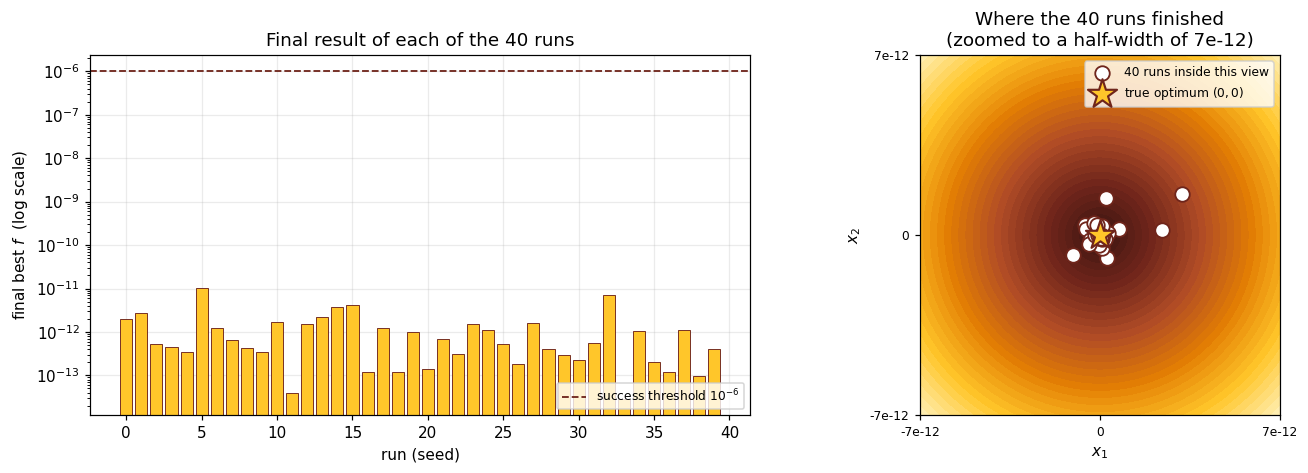

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4))

ax = axes[0]
ax.bar(np.arange(N_RUNS), np.maximum(run_values, 1e-18),
       color=[AMBER if p else "#B04B26" for p in precise], edgecolor=BROWN, linewidth=0.6)
ax.set_yscale("log")
ax.axhline(1e-6, color=BROWN, linestyle="--", linewidth=1.2,
           label="success threshold $10^{-6}$")
ax.set_xlabel("run (seed)"); ax.set_ylabel("final best $f$  (log scale)")
ax.set_title("Final result of each of the %d runs" % N_RUNS)
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
half = max(2.2 * np.abs(run_solutions).max(), 1e-13)
g = np.linspace(-half, half, 200)
A, B = np.meshgrid(g, g)
ax.contourf(A, B, ackley(np.stack([A, B], axis=-1)), levels=45, cmap=HONEY)
ax.scatter(run_solutions[in_valley, 0], run_solutions[in_valley, 1], s=90, color="white",
           edgecolor=BROWN, linewidth=1.2, zorder=4,
           label="%d runs inside this view" % in_valley.sum())
ax.scatter(0, 0, marker="*", s=400, color=AMBER, edgecolors=BROWN, linewidths=1.4,
           zorder=6, label="true optimum $(0,0)$")
ax.set_xlim(-half, half); ax.set_ylim(-half, half); ax.set_aspect("equal")
ax.set_xticks([-half, 0, half]); ax.set_yticks([-half, 0, half])
ax.set_xticklabels([f"{-half:.0e}", "0", f"{half:.0e}"], fontsize=8)
ax.set_yticklabels([f"{-half:.0e}", "0", f"{half:.0e}"], fontsize=8)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Where the %d runs finished\n(zoomed to a half-width of %.0e)" % (N_RUNS, half))
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 29. Same-budget random-search baseline

- Give random search exactly the same number of Ackley evaluations as the main ABC run.
- Use the same seed for a reproducible comparison.
- Compare the smallest random-search value with the ABC result.

In [30]:
budget = result["evaluations"]
baseline_rng = np.random.default_rng(SETTINGS.seed)
random_points = baseline_rng.uniform(SETTINGS.lower, SETTINGS.upper, size=(budget, 2))
random_best = float(ackley(random_points).min())

print("Ackley evaluations allowed to both methods : %d" % budget)
print()
print("pure random search       : f = %.6e" % random_best)
print("artificial bee colony    : f = %.6e" % best_f)
print()
print("Both looked at the same number of points. The bees chose where to look next")
print("using what the colony had already learned; random search did not.")

Ackley evaluations allowed to both methods : 5025

pure random search       : f = 7.693070e-01
artificial bee colony    : f = 6.541434e-13

Both looked at the same number of points. The bees chose where to look next
using what the colony had already learned; random search did not.


## 30. ABC next to the Genetic Algorithm

The sister notebook solves the identical problem with a Genetic Algorithm. Both were run on
the same 40 seeds with practically the same evaluation budget, so the comparison is fair.

| | Genetic Algorithm | Artificial Bee Colony |
|---|---|---|
| Ackley evaluations | 5,050 | 5,025 |
| Best of 40 runs | $1.106\times10^{-13}$ | $2.887\times10^{-14}$ |
| **Median of 40 runs** | $1.636\times10^{-12}$ | $5.476\times10^{-13}$ |
| Worst of 40 runs | $3.137\times10^{-11}$ | $1.034\times10^{-11}$ |
| Runs below $10^{-6}$ | 40 / 40 | 40 / 40 |
| Operators to tune | crossover rate, mutation rate, mutation step rule, elitism, duplicate cap | `limit` |

Both methods solve this problem reliably. ABC reached a median about **three times closer** to
zero, and it did so with far fewer things to tune: the GA version needed a hand-designed
mutation-step schedule and a duplicate cap, while ABC gets its step size from the colony itself.

This is one problem at one size. It is evidence, not proof that ABC is the better algorithm in
general.

## Result

For seed 7, ABC returns a point about $2\times10^{-13}$ away from $(0,0)$, with an Ackley value
near $6.5\times10^{-13}$. All 40 tested seeds finish below the success threshold of $10^{-6}$.

The experiment shows the separate roles of the employed bees (local refinement), the onlookers
(extra effort aimed at good sources, and the part that supplies the final precision), the scouts
(an escape route that this problem never needed), and the `limit` parameter that decides how
patient the colony is.